### Анализ изменения концентрации поставщиков, волатильности и сезонности по блокам стран

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory
from scipy.stats import levene, fligner, bartlett
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_arch

warnings.filterwarnings("ignore")

#### Подготовка данных

In [2]:
df = pd.read_excel('data/final_data.xlsx')
df["rep_date"] = pd.to_datetime(df["rep_date"])
df = df.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

shock_date = pd.Timestamp("2022-02-01")

save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

In [3]:
# Убедимся, что блоковые переменные бинарные
for col in ["unfriendly", "brics", "cis"]:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

In [4]:
def human_format(x, pos):
    """
    Красивый формат чисел на оси Y:
    1 200 000 000 -> 1.2B
    35 000 000    -> 35M
    8 000         -> 8K
    """
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


def percent_format(x, pos):
    """Формат процентов для оси Y."""
    return f"{x:.0f}%"


def apply_thesis_style(ax, title, ylabel=None, xlabel=None, highlight_post_period=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if highlight_post_period:
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        trans = blended_transform_factory(ax.transData, ax.transAxes)
        x_text = x_right - 0.02 * (x_right - x_left)

        ax.text(
            x_text, 0.04,
            "Постсанкционный период",
            transform=trans,
            color="#8B0000",
            fontsize=10,
            ha="right",
            va="bottom",
            linespacing=1.0
        )

def save_figure(fig, filename):
    png_path = os.path.join(save_dir, f"{filename}.png")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")

    # pdf_path = os.path.join(save_dir, f"{filename}.pdf")
    # fig.savefig(pdf_path, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [5]:
# MUTUALLY EXCLUSIVE BLOCS
def assign_exclusive_bloc(row):
    """
    Priority:
    1) CIS
    2) BRICS non-CIS
    3) Unfriendly non-CIS non-BRICS
    4) Others
    """
    if row["cis"] == 1:
        return "cis"
    elif row["brics"] == 1:
        return "brics"
    elif row["unfriendly"] == 1:
        return "unfriendly"
    else:
        return "others"

df["bloc_exclusive"] = df.apply(assign_exclusive_bloc, axis=1)

print(df["bloc_exclusive"].value_counts(dropna=False))

bloc_exclusive
unfriendly    30186
others         9126
cis            4914
brics          4212
Name: count, dtype: int64


In [6]:
early_post_end = pd.Timestamp("2023-03-01")

# AGGREGATED IMPORT SERIES
agg_import = (
    df.groupby("rep_date", as_index=False)["value"]
      .sum()
      .rename(columns={"value": "import_value"})
      .sort_values("rep_date")
      .reset_index(drop=True)
)

agg_import["log_import"] = np.log1p(agg_import["import_value"])
agg_import["month"] = agg_import["rep_date"].dt.month
agg_import["month_cat"] = agg_import["month"].astype("category")
agg_import["trend"] = np.arange(len(agg_import))
agg_import["post"] = (agg_import["rep_date"] >= shock_date).astype(int)
agg_import["early_post"] = (
    (agg_import["rep_date"] >= shock_date) &
    (agg_import["rep_date"] < early_post_end)
).astype(int)

# HHI SERIES
monthly_country = (
    df.groupby(["rep_date", "country"], as_index=False)["value"]
      .sum()
)

monthly_total = (
    monthly_country.groupby("rep_date", as_index=False)["value"]
      .sum()
      .rename(columns={"value": "total_value"})
)

monthly_country = monthly_country.merge(monthly_total, on="rep_date", how="left")
monthly_country["share"] = monthly_country["value"] / monthly_country["total_value"]

hhi_series = (
    monthly_country.groupby("rep_date", as_index=False)["share"]
    .apply(lambda x: np.sum(np.square(x)))
    .rename(columns={"share": "hhi"})
    .sort_values("rep_date")
    .reset_index(drop=True)
)

hhi_series["trend"] = np.arange(len(hhi_series))
hhi_series["post"] = (hhi_series["rep_date"] >= shock_date).astype(int)

In [7]:
# FOURIER TERMS FOR ALTERNATIVE DESEASONALIZATION
def add_fourier_terms(df_in: pd.DataFrame, period: int = 12, K: int = 2, time_col: str = "trend") -> pd.DataFrame:
    """
    Добавляет Fourier terms:
    sin(2*pi*k*t/period), cos(2*pi*k*t/period)
    """
    out = df_in.copy()
    t = out[time_col].values.astype(float)

    for k in range(1, K + 1):
        out[f"sin{k}"] = np.sin(2 * np.pi * k * t / period)
        out[f"cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return out

agg_import = add_fourier_terms(agg_import, period=12, K=2, time_col="trend")

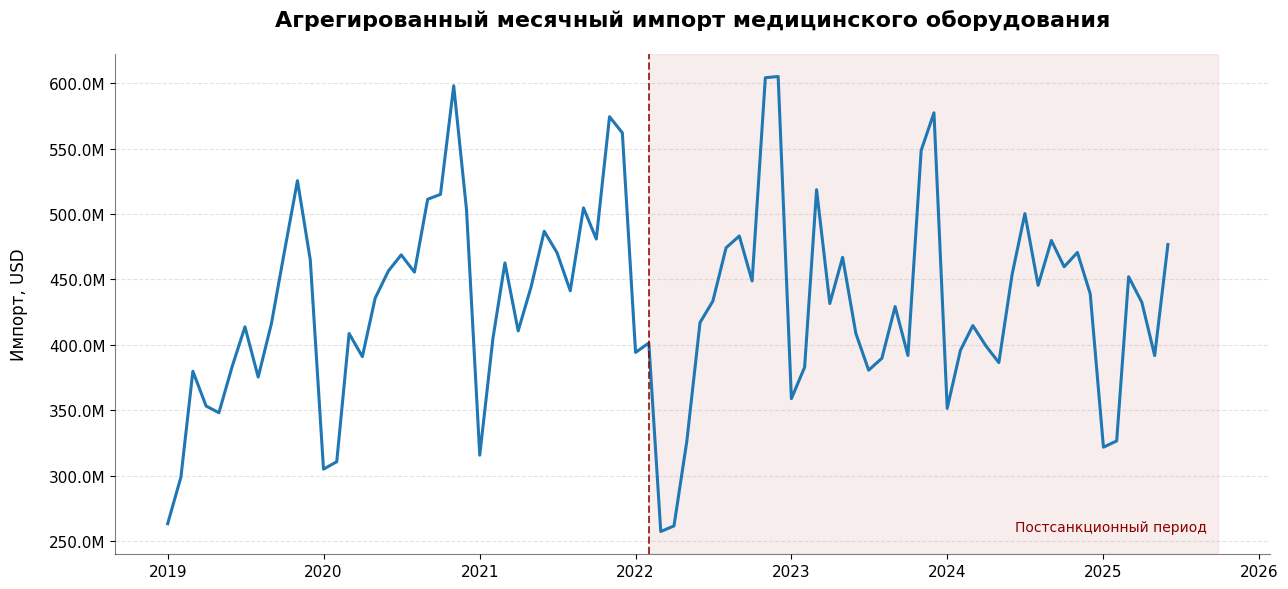

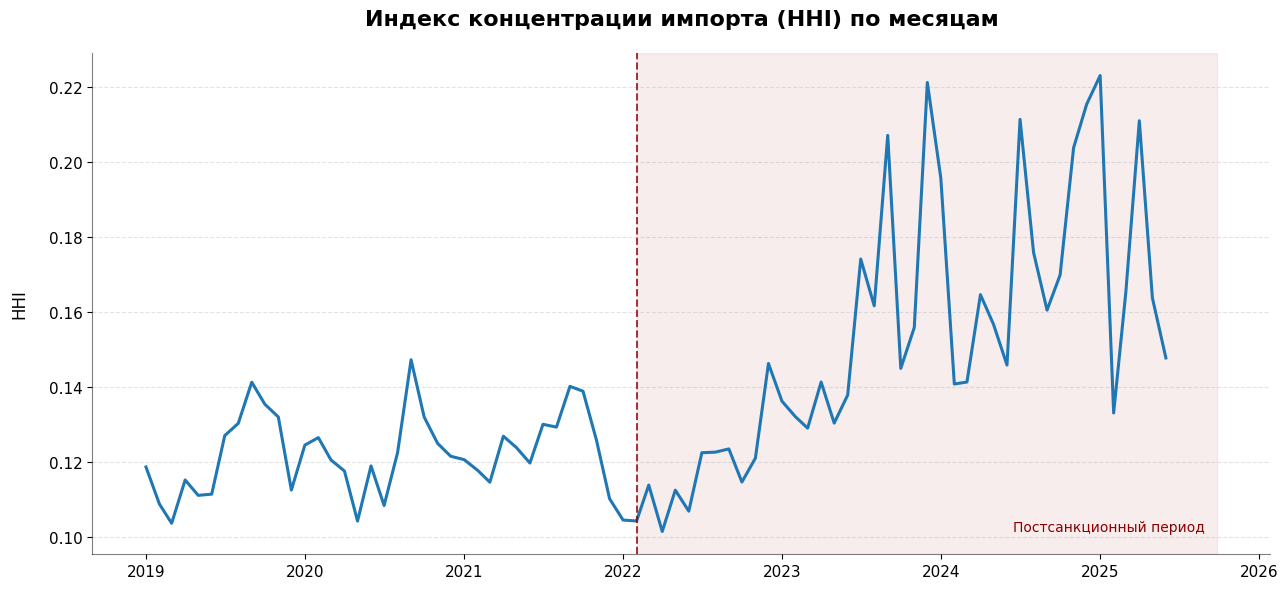

In [8]:
# PLOT AGGREGATED IMPORT
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(agg_import["rep_date"], agg_import["import_value"], linewidth=2.2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(human_format))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="Агрегированный месячный импорт медицинского оборудования",
    ylabel="Импорт, USD"
)
save_figure(fig, "agg_import_series")

# PLOT HHI
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(hhi_series["rep_date"], hhi_series["hhi"], linewidth=2.2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.2f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="Индекс концентрации импорта (HHI) по месяцам",
    ylabel="HHI"
)
save_figure(fig, "hhi_series")

### HHI: структурный перелом

In [9]:
# HHI STRUCTURAL BREAK: KNOWN BREAK
hhi_break_model = smf.ols(
    "hhi ~ trend + post + trend:post",
    data=hhi_series
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(hhi_break_model.summary())

hhi_break_wald = hhi_break_model.wald_test("post = 0, trend:post = 0")
print("\nHHI structural break joint test:")
print(hhi_break_wald)

                            OLS Regression Results                            
Dep. Variable:                    hhi   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     33.28
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.00e-13
Time:                        03:41:56   Log-Likelihood:                 198.18
No. Observations:                  78   AIC:                            -388.4
Df Residuals:                      74   BIC:                            -378.9
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1188      0.003     37.422      0.0

In [10]:
# HHI BREAK SEARCH OVER DATES
def fit_hhi_break_for_date(data: pd.DataFrame, break_date_candidate: pd.Timestamp) -> dict:
    tmp = data.copy()
    tmp["post_cand"] = (tmp["rep_date"] >= break_date_candidate).astype(int)

    model = smf.ols(
        "hhi ~ trend + post_cand + trend:post_cand",
        data=tmp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    test_res = model.wald_test("post_cand = 0, trend:post_cand = 0")

    return {
        "break_date": break_date_candidate,
        "wald_stat": float(test_res.statistic),
        "pvalue": float(test_res.pvalue),
        "aic": model.aic,
        "bic": model.bic
    }

candidate_dates_hhi = hhi_series["rep_date"].iloc[18:-18]

hhi_break_search = pd.DataFrame(
    [fit_hhi_break_for_date(hhi_series, d) for d in candidate_dates_hhi]
).sort_values("wald_stat", ascending=False)

print(hhi_break_search.head(10))

   break_date  wald_stat        pvalue         aic         bic
29 2022-12-01  60.531395  7.174218e-14 -390.576505 -381.149670
36 2023-07-01  53.507737  2.404044e-12 -396.178619 -386.751784
28 2022-11-01  51.914293  5.332791e-12 -389.364829 -379.937994
30 2023-01-01  51.575105  6.318415e-12 -388.681776 -379.254941
33 2023-04-01  47.648873  4.499650e-11 -390.734211 -381.307376
31 2023-02-01  47.098072  5.926299e-11 -388.409222 -378.982387
32 2023-03-01  45.921138  1.067460e-10 -389.050250 -379.623415
35 2023-06-01  45.847190  1.107667e-10 -393.748935 -384.322100
27 2022-10-01  43.412665  3.741619e-10 -387.966907 -378.540071
34 2023-05-01  39.494636  2.653681e-09 -390.748796 -381.321960


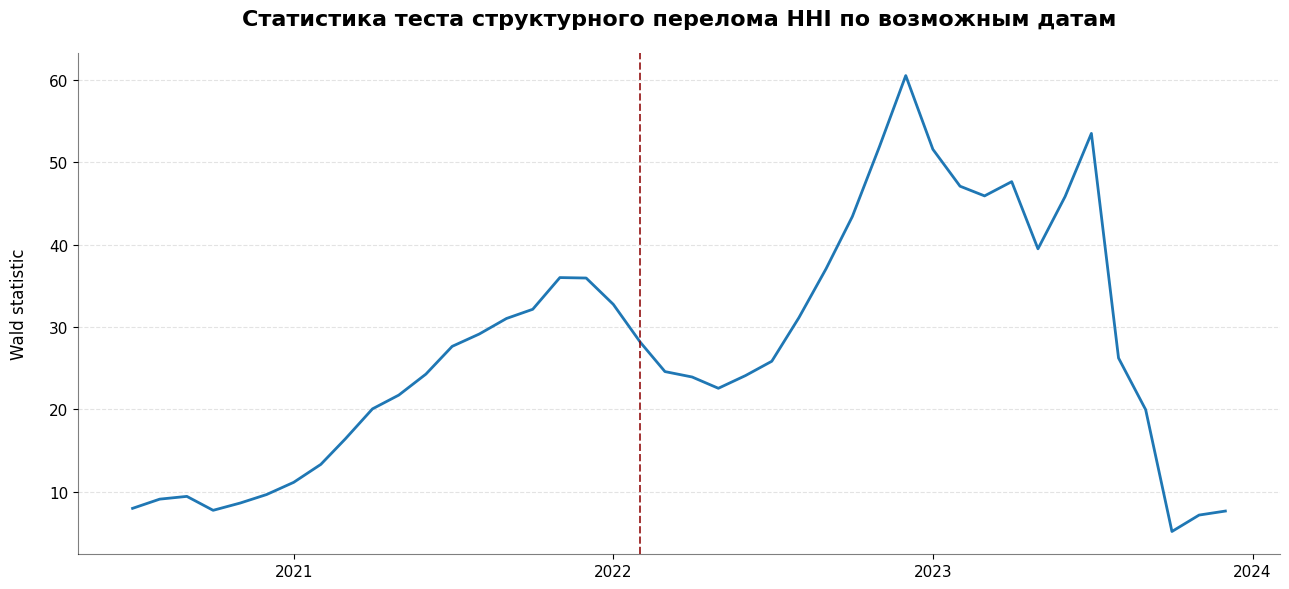

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
hhi_break_search = hhi_break_search.sort_values(by='break_date')
ax.plot(hhi_break_search["break_date"], hhi_break_search["wald_stat"], linewidth=2.0)
ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="Статистика теста структурного перелома HHI по возможным датам",
    ylabel="Wald statistic",
    highlight_post_period=False
)
save_figure(fig, "hhi_break_search")

In [12]:
# HHI BY HS AND MONTH
monthly_country_hs = (
    df.groupby(["rep_date", "hs", "country"], as_index=False)["value"]
      .sum()
)

monthly_total_hs = (
    monthly_country_hs.groupby(["rep_date", "hs"], as_index=False)["value"]
      .sum()
      .rename(columns={"value": "total_value_hs"})
)

monthly_country_hs = monthly_country_hs.merge(
    monthly_total_hs,
    on=["rep_date", "hs"],
    how="left"
)

monthly_country_hs["share_hs"] = (
    monthly_country_hs["value"] / monthly_country_hs["total_value_hs"]
)

hhi_hs_series = (
    monthly_country_hs.groupby(["rep_date", "hs"], as_index=False)["share_hs"]
    .apply(lambda x: np.sum(np.square(x)))
    .rename(columns={"share_hs": "hhi_hs"})
    .sort_values(["hs", "rep_date"])
    .reset_index(drop=True)
)

hhi_hs_series["trend"] = hhi_hs_series.groupby("hs").cumcount()
hhi_hs_series["post"] = (hhi_hs_series["rep_date"] >= shock_date).astype(int)

print(hhi_hs_series.head())

    rep_date    hs    hhi_hs  trend  post
0 2019-01-01  9018  0.140838      0     0
1 2019-02-01  9018  0.110131      1     0
2 2019-03-01  9018  0.104352      2     0
3 2019-04-01  9018  0.121311      3     0
4 2019-05-01  9018  0.117244      4     0


In [13]:
# STRUCTURAL BREAK TEST FOR EACH HS
def run_hhi_break_by_hs(grp: pd.DataFrame, hs_code) -> pd.DataFrame:
    model = smf.ols(
        "hhi_hs ~ trend + post + trend:post",
        data=grp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    joint_test = model.wald_test("post = 0, trend:post = 0")

    return pd.DataFrame({
        "hs": [hs_code],
        "n_obs": [len(grp)],
        "coef_post": [model.params.get("post", np.nan)],
        "p_post": [model.pvalues.get("post", np.nan)],
        "coef_trend_post": [model.params.get("trend:post", np.nan)],
        "p_trend_post": [model.pvalues.get("trend:post", np.nan)],
        "wald_stat": [float(joint_test.statistic)],
        "wald_pvalue": [float(joint_test.pvalue)],
        "r2": [model.rsquared]
    })

hhi_hs_break_results = pd.concat(
    [
        run_hhi_break_by_hs(grp.copy(), hs_code)
        for hs_code, grp in hhi_hs_series.groupby("hs")
    ],
    ignore_index=True
).sort_values("wald_stat", ascending=False)

hhi_hs_break_results

,hs,n_obs,coef_post,p_post,coef_trend_post,p_trend_post,wald_stat,wald_pvalue,r2
8,9031,78,-0.242407,1.542608e-01,0.013480,6.206300e-06,290.843087,6.985961e-64,0.906726
2,9020,78,0.258774,1.189006e-02,0.002381,1.264038e-01,184.881447,7.136807e-41,0.767619
5,9025,78,-0.254097,4.999271e-03,0.010222,4.916944e-08,151.040374,1.592207e-33,0.845955
6,9027,78,-0.284975,5.668234e-05,0.007619,3.702801e-09,72.868894,1.502176e-16,0.783944
1,9019,78,-0.234953,1.308708e-16,0.005994,7.386571e-14,71.313265,3.269800e-16,0.657654
0,9018,78,-0.027532,3.526965e-06,0.000133,4.947734e-01,43.712842,3.220156e-10,0.147734
4,9022,78,0.031394,3.077845e-03,-0.000013,9.621676e-01,37.665325,6.623364e-09,0.267610
7,9030,78,-0.201057,1.473365e-01,0.008333,5.670143e-03,17.802150,1.362424e-04,0.839165
3,9021,78,0.033058,2.131752e-01,-0.000896,6.775939e-02,3.696439,1.575174e-01,0.140592


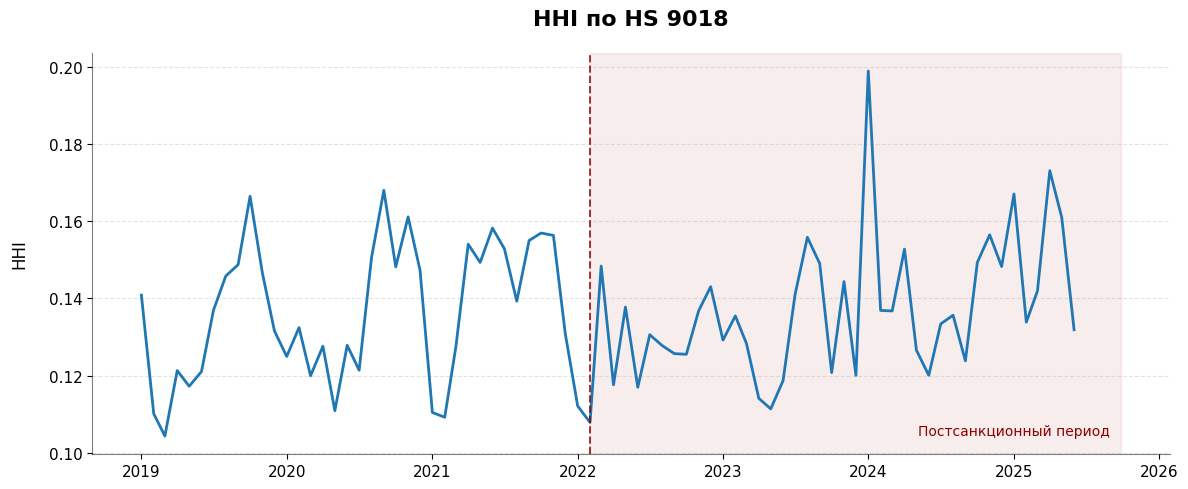

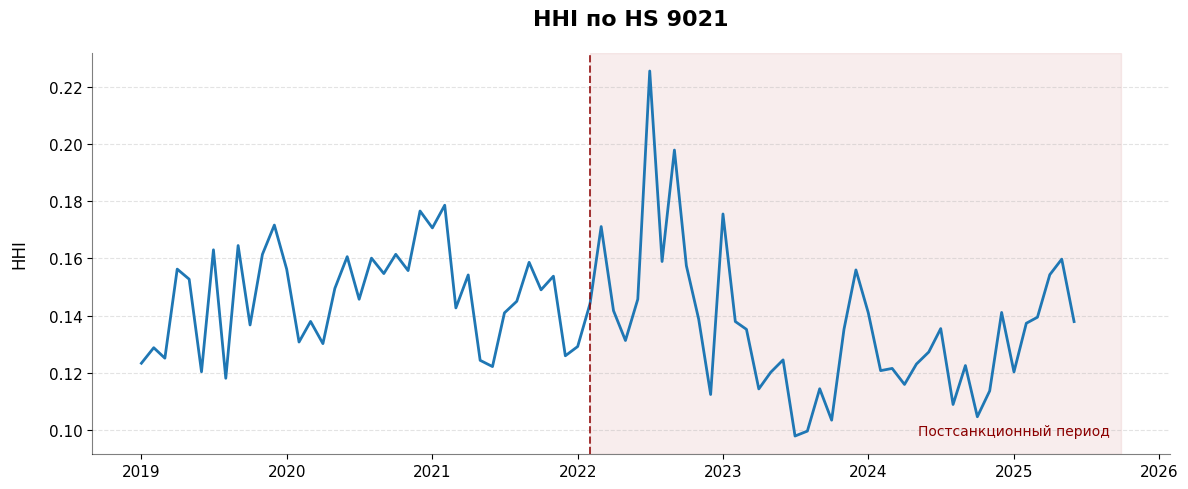

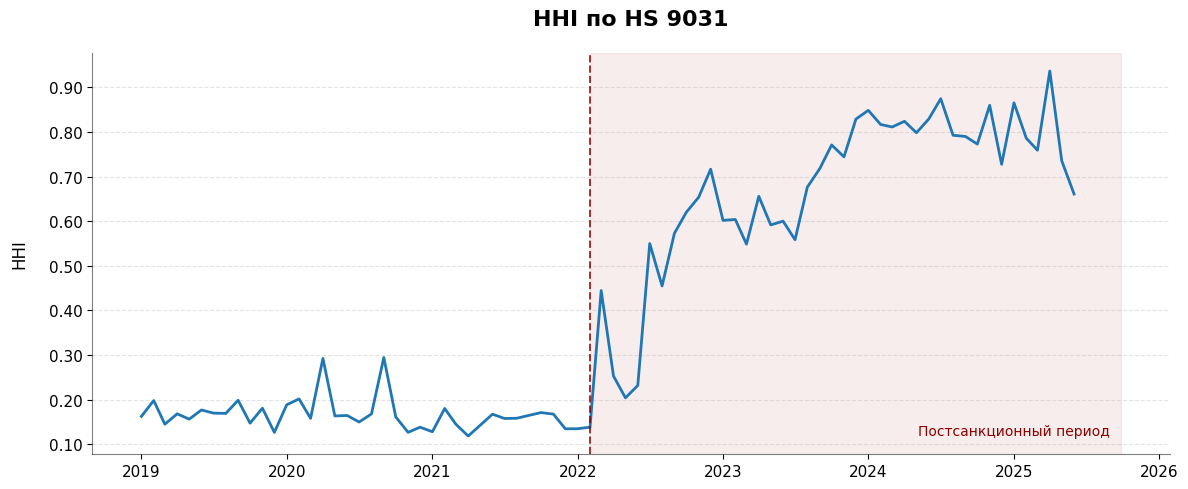

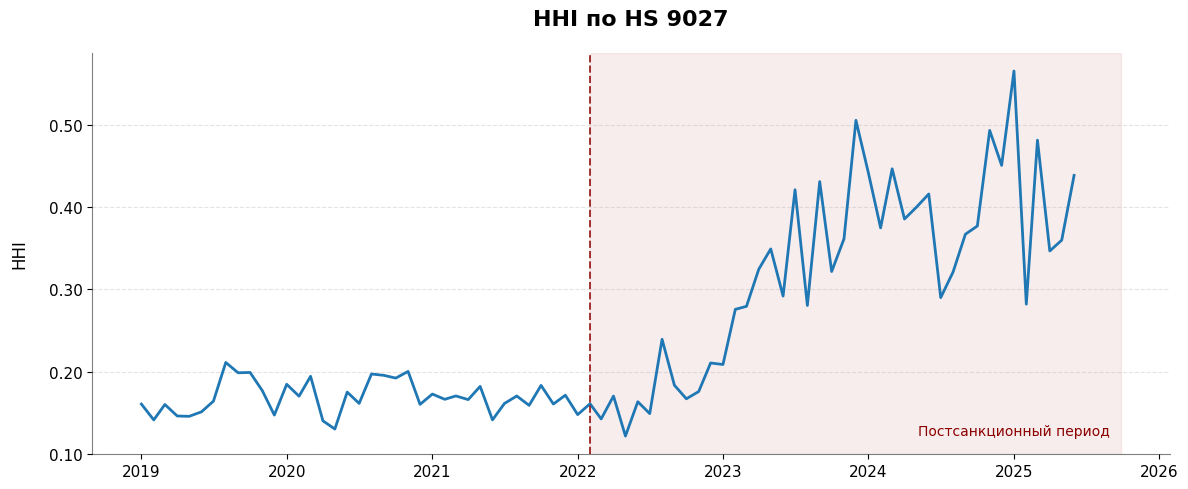

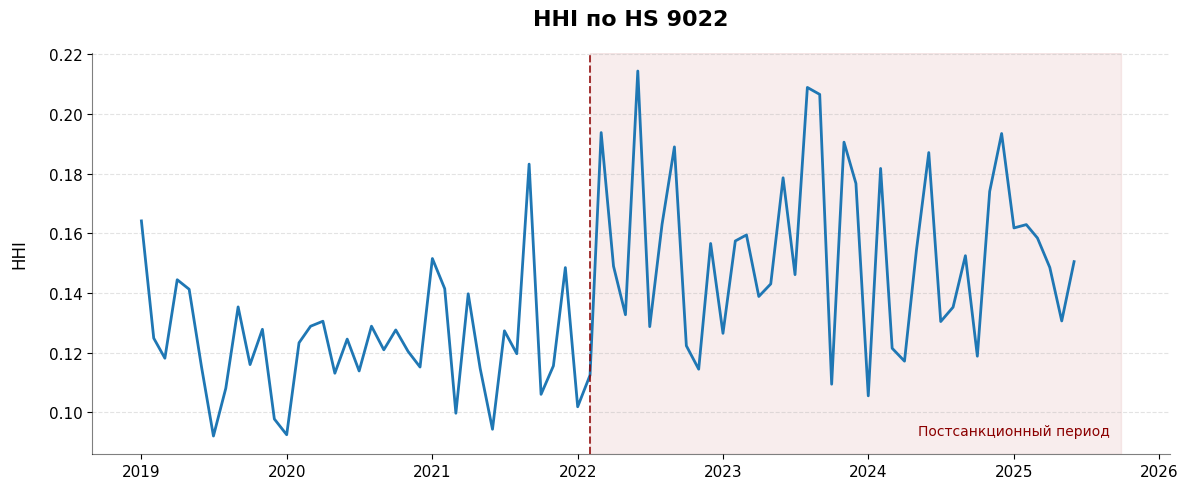

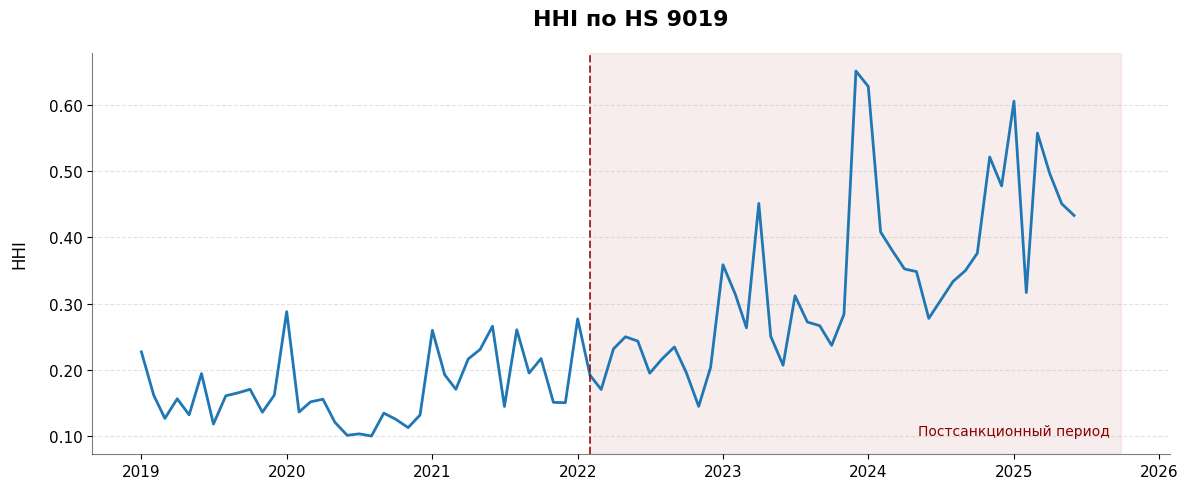

In [14]:
# PLOT HHI BY HS (TOP HS CODES)
top_hs = (
    df.groupby("hs")["value"].sum()
      .sort_values(ascending=False)
      .head(6)
      .index
      .tolist()
)

for hs_code in top_hs:
    tmp = hhi_hs_series[hhi_hs_series["hs"] == hs_code].copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tmp["rep_date"], tmp["hhi_hs"], linewidth=2.0)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:.2f}"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    apply_thesis_style(
        ax,
        title=f"HHI по HS {hs_code}",
        ylabel="HHI",
        highlight_post_period=True
    )
    save_figure(fig, f"hhi_hs_{hs_code}")

In [15]:
# POOLED HHI-HS BREAK MODEL
pooled_hhi_hs_model = smf.ols(
    "hhi_hs ~ C(hs) + trend + post + trend:post",
    data=hhi_hs_series
).fit(cov_type="cluster", cov_kwds={"groups": hhi_hs_series["hs"]})

print(pooled_hhi_hs_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 hhi_hs   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     4.452
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0405
Time:                        03:42:01   Log-Likelihood:                 472.96
No. Observations:                 702   AIC:                            -921.9
Df Residuals:                     690   BIC:                            -867.3
Df Model:                          11                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0121      0.035      0.342

### Агрегированный импорт: изменение волатильности

In [16]:
# MAIN DESEASONALIZATION: MONTH DUMMIES
import_deseason_model = smf.ols(
    "log_import ~ trend + C(month_cat)",
    data=agg_import
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(import_deseason_model.summary())

agg_import["resid_import_main"] = import_deseason_model.resid
agg_import["abs_resid_import_main"] = agg_import["resid_import_main"].abs()
agg_import["sq_resid_import_main"] = agg_import["resid_import_main"] ** 2

                            OLS Regression Results                            
Dep. Variable:             log_import   R-squared:                       0.598
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     34.68
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.29e-23
Time:                        03:42:01   Log-Likelihood:                 55.405
No. Observations:                  78   AIC:                            -84.81
Df Residuals:                      65   BIC:                            -54.17
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             19.5705      0

In [17]:
# ALTERNATIVE DESEASONALIZATION: FOURIER TERMS
import_deseason_fourier = smf.ols(
    "log_import ~ trend + sin1 + cos1 + sin2 + cos2",
    data=agg_import
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(import_deseason_fourier.summary())

agg_import["resid_import_fourier"] = import_deseason_fourier.resid
agg_import["abs_resid_import_fourier"] = agg_import["resid_import_fourier"].abs()
agg_import["sq_resid_import_fourier"] = agg_import["resid_import_fourier"] ** 2

                            OLS Regression Results                            
Dep. Variable:             log_import   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     17.99
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.54e-11
Time:                        03:42:02   Log-Likelihood:                 39.080
No. Observations:                  78   AIC:                            -66.16
Df Residuals:                      72   BIC:                            -52.02
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.8279      0.049    407.623      0.0

In [18]:
from statsmodels.tsa.seasonal import STL

# -----------------------------
# STL DESEASONALIZATION
# -----------------------------
# period=12 для месячных данных
stl = STL(
    agg_import["log_import"],
    period=12,
    robust=True
)

stl_res = stl.fit()

agg_import["stl_trend"] = stl_res.trend
agg_import["stl_seasonal"] = stl_res.seasonal
agg_import["resid_import_stl"] = stl_res.resid
agg_import["abs_resid_import_stl"] = agg_import["resid_import_stl"].abs()
agg_import["sq_resid_import_stl"] = agg_import["resid_import_stl"] ** 2

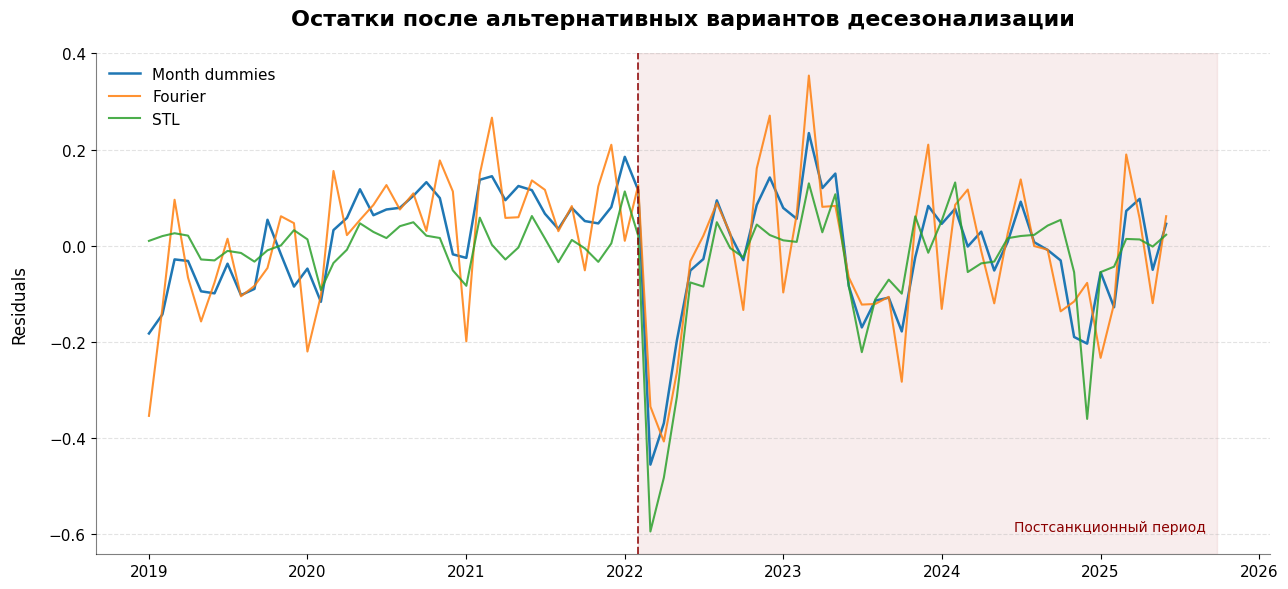

KeyError: 'roll12_std_main'

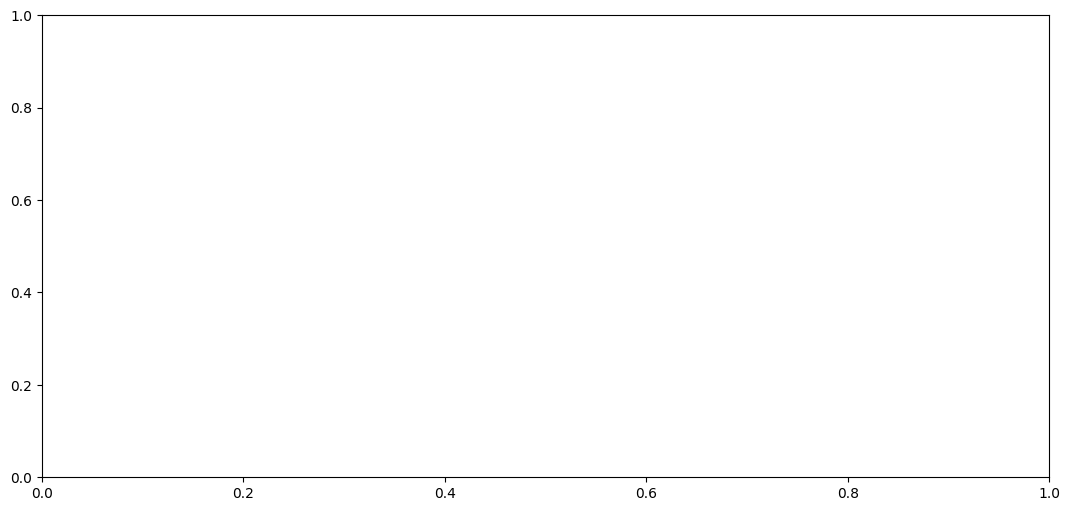

In [19]:
# COMPARE RESIDUALS: MONTH DUMMIES / FOURIER / STL
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(agg_import["rep_date"], agg_import["resid_import_main"], linewidth=1.8, label="Month dummies")
ax.plot(agg_import["rep_date"], agg_import["resid_import_fourier"], linewidth=1.5, alpha=0.85, label="Fourier")
ax.plot(agg_import["rep_date"], agg_import["resid_import_stl"], linewidth=1.5, alpha=0.85, label="STL")

ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="Остатки после альтернативных вариантов десезонализации",
    ylabel="Residuals"
)
save_figure(fig, "agg_import_residuals_compare_3ways")

# COMPARE ROLLING VOLATILITY: 3 METHODS
agg_import["roll12_std_stl"] = agg_import["resid_import_stl"].rolling(12, min_periods=6).std()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(agg_import["rep_date"], agg_import["roll12_std_main"], linewidth=2.2, label="Month dummies")
ax.plot(agg_import["rep_date"], agg_import["roll12_std_fourier"], linewidth=1.8, alpha=0.85, label="Fourier")
ax.plot(agg_import["rep_date"], agg_import["roll12_std_stl"], linewidth=1.8, alpha=0.85, label="STL")

ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="12-месячная скользящая волатильность: сравнение методов десезонализации",
    ylabel="Rolling SD of residuals"
)
save_figure(fig, "agg_import_rolling_volatility_compare_3ways")

#### SEASONALITY CHANGE TEST: AGGREGATE IMPORT

In [ ]:
season_change_model = smf.ols(
    "log_import ~ trend + C(month_cat) + post + C(month_cat):post",
    data=agg_import
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(season_change_model.summary())

interaction_terms = [
    term for term in season_change_model.params.index
    if ":post" in term
]

wald_formula = " = 0, ".join(interaction_terms) + " = 0"
seasonality_wald = season_change_model.wald_test(wald_formula)

print("\nSeasonality change joint test:")
print(seasonality_wald)

                            OLS Regression Results                            
Dep. Variable:             log_import   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     104.6
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.85e-36
Time:                        19:57:16   Log-Likelihood:                 64.342
No. Observations:                  78   AIC:                            -78.68
Df Residuals:                      53   BIC:                            -19.77
Df Model:                          24                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

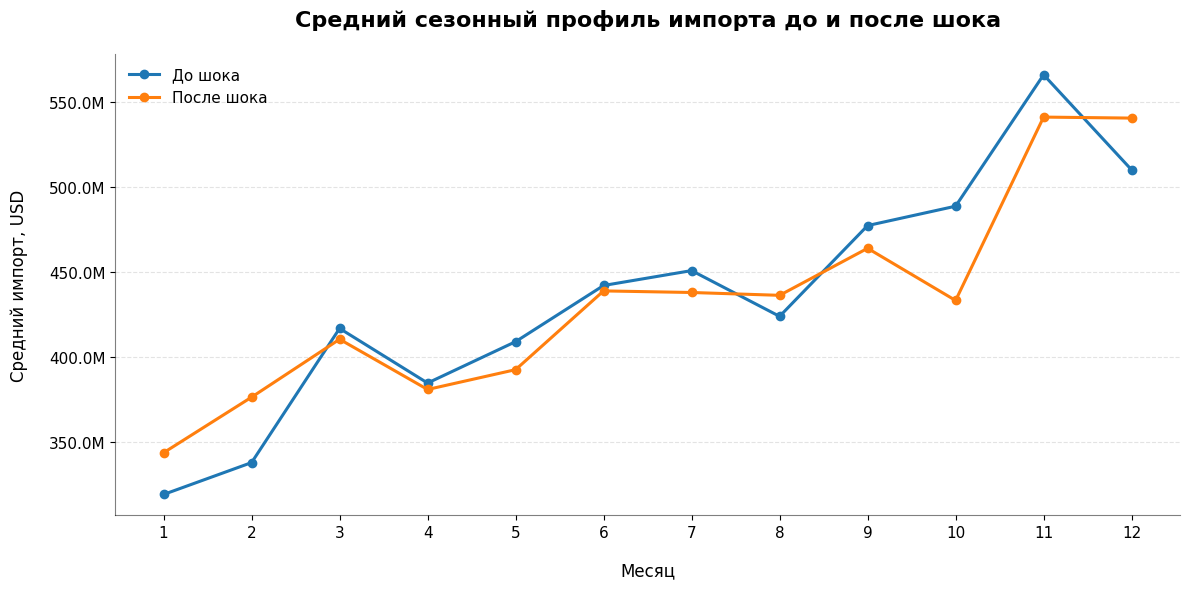

In [20]:
# PLOT SEASONAL PROFILE PRE VS POST
season_profile = (
    agg_import.groupby(["post", "month"], as_index=False)["import_value"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

pre_prof = season_profile[season_profile["post"] == 0]
post_prof = season_profile[season_profile["post"] == 1]

ax.plot(pre_prof["month"], pre_prof["import_value"], marker="o", linewidth=2.2, label="До шока")
ax.plot(post_prof["month"], post_prof["import_value"], marker="o", linewidth=2.2, label="После шока")
ax.legend(frameon=False, fontsize=11)

ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

apply_thesis_style(
    ax,
    title="Средний сезонный профиль импорта до и после шока",
    ylabel="Средний импорт, USD",
    xlabel="Месяц",
    highlight_post_period=False
)
save_figure(fig, "seasonal_profile_pre_post")

In [21]:
# AGGREGATED MONTHLY SERIES BY EXCLUSIVE BLOC
bloc_monthly = (
    df.groupby(["rep_date", "bloc_exclusive"], as_index=False)["value"]
      .sum()
      .rename(columns={"value": "import_value"})
      .sort_values(["bloc_exclusive", "rep_date"])
      .reset_index(drop=True)
)

bloc_monthly["log_import"] = np.log1p(bloc_monthly["import_value"])
bloc_monthly["month"] = bloc_monthly["rep_date"].dt.month
bloc_monthly["month_cat"] = bloc_monthly["month"].astype("category")
bloc_monthly["post"] = (bloc_monthly["rep_date"] >= shock_date).astype(int)

# trend внутри каждого блока
bloc_monthly["trend"] = bloc_monthly.groupby("bloc_exclusive").cumcount()

# Fourier terms внутри каждого блока
bloc_monthly = add_fourier_terms(bloc_monthly, period=12, K=2, time_col="trend")

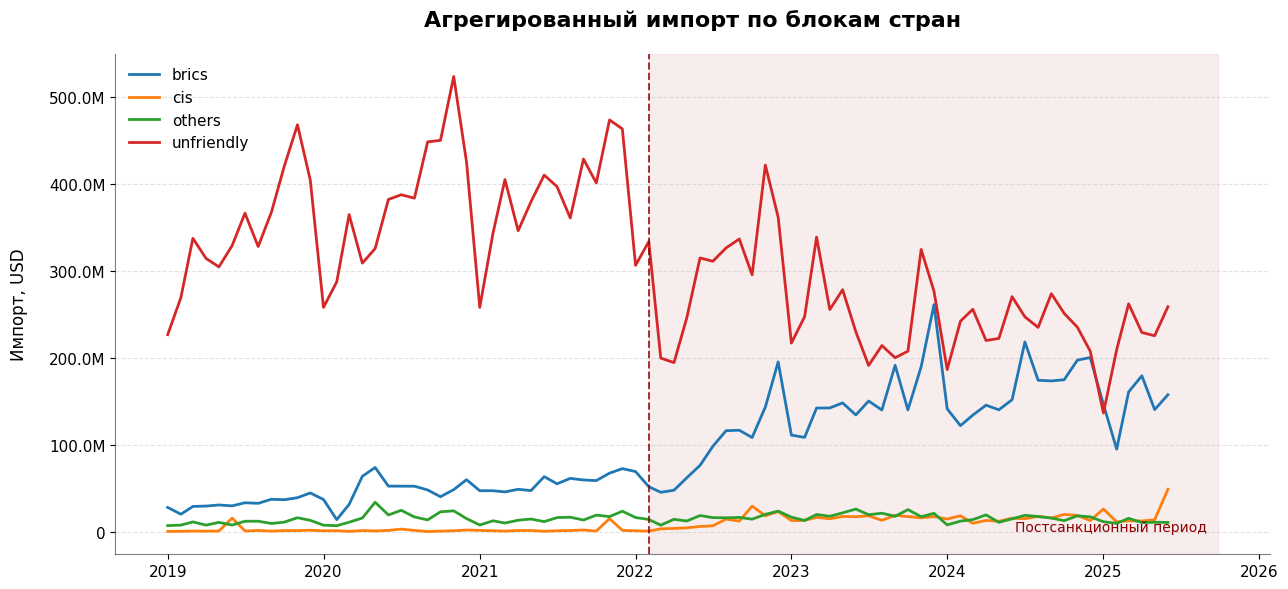

In [22]:
# PLOT IMPORT SERIES BY BLOC
fig, ax = plt.subplots(figsize=(13, 6))

for bloc_name, grp in bloc_monthly.groupby("bloc_exclusive"):
    ax.plot(grp["rep_date"], grp["import_value"], linewidth=2.0, label=bloc_name)

ax.legend(frameon=False, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(human_format))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_thesis_style(
    ax,
    title="Агрегированный импорт по блокам стран",
    ylabel="Импорт, USD"
)
save_figure(fig, "bloc_import_series")

In [23]:
# FUNCTION: SEASONALITY CHANGE TEST FOR A BLOC
def run_bloc_seasonality_test(bloc_df: pd.DataFrame, bloc_name: str) -> tuple:
    model = smf.ols(
        "log_import ~ trend + C(month_cat) + post + C(month_cat):post",
        data=bloc_df
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    interaction_terms = [
        term for term in model.params.index
        if ":post" in term
    ]

    wald_formula = " = 0, ".join(interaction_terms) + " = 0"
    wald_res = model.wald_test(wald_formula)

    out_row = pd.DataFrame({
        "bloc": [bloc_name],
        "n_obs": [len(bloc_df)],
        "wald_stat": [float(wald_res.statistic)],
        "pvalue": [float(wald_res.pvalue)]
    })
    return model, out_row

In [24]:
# RUN SEASONALITY TESTS BY BLOC
bloc_seasonality_rows = []
bloc_seasonality_models = {}

for bloc_name, grp in bloc_monthly.groupby("bloc_exclusive"):
    model, row = run_bloc_seasonality_test(grp.copy(), bloc_name)
    bloc_seasonality_models[bloc_name] = model
    bloc_seasonality_rows.append(row)

bloc_seasonality_results = pd.concat(bloc_seasonality_rows, ignore_index=True)
print(bloc_seasonality_results)

         bloc  n_obs  wald_stat        pvalue
0       brics     78  69.192373  1.739196e-10
1         cis     78  54.698335  8.799938e-08
2      others     78  73.255318  2.925874e-11
3  unfriendly     78  30.965584  1.115489e-03


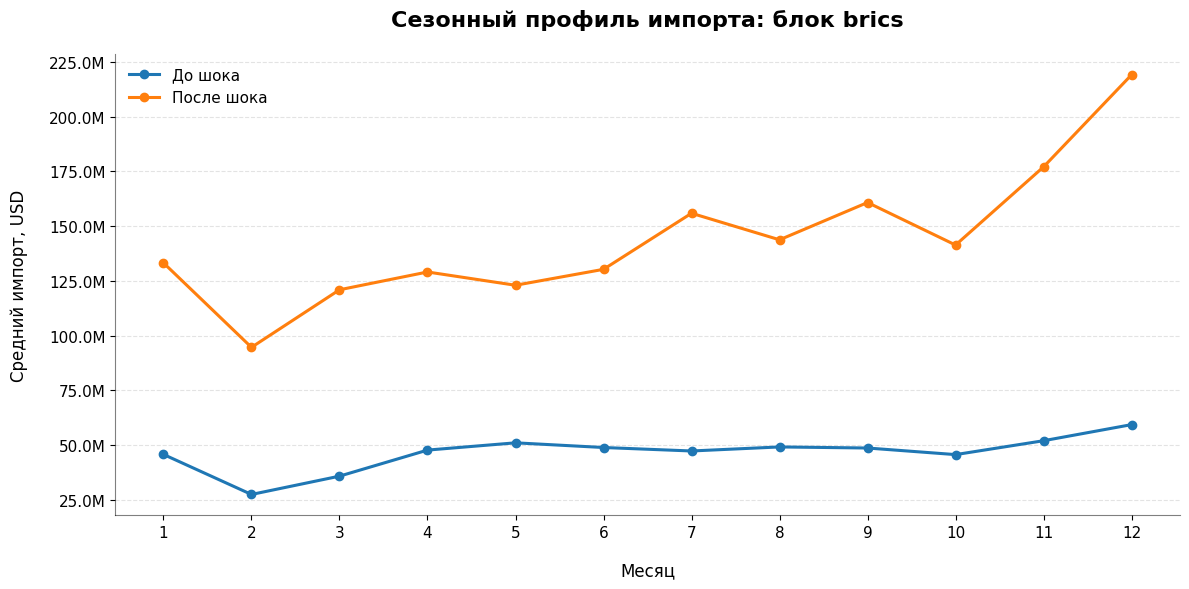

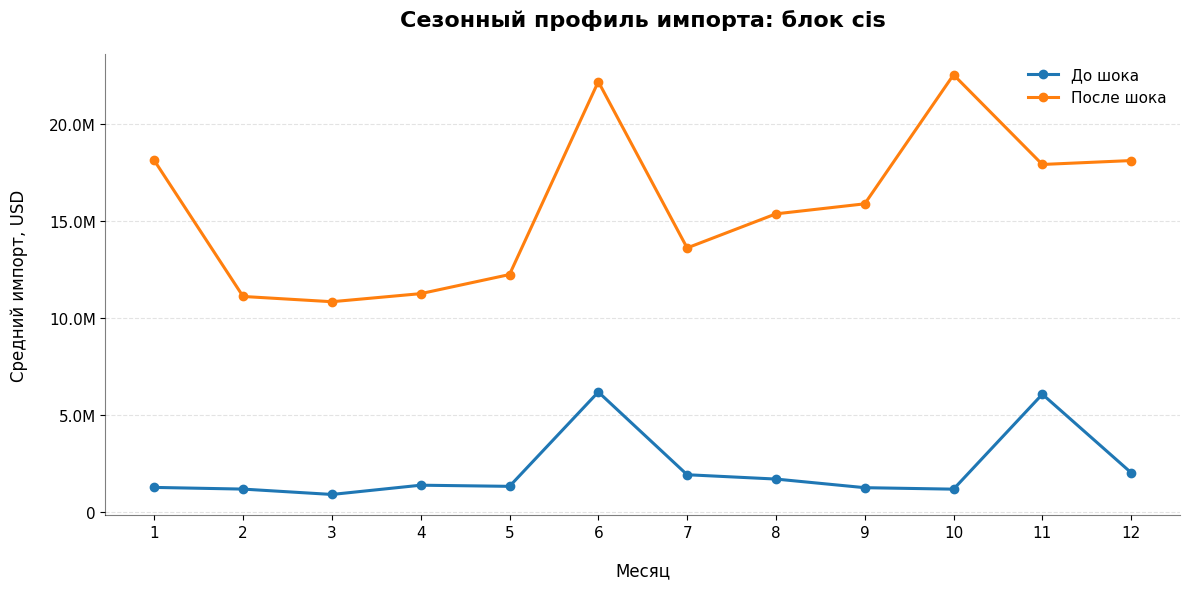

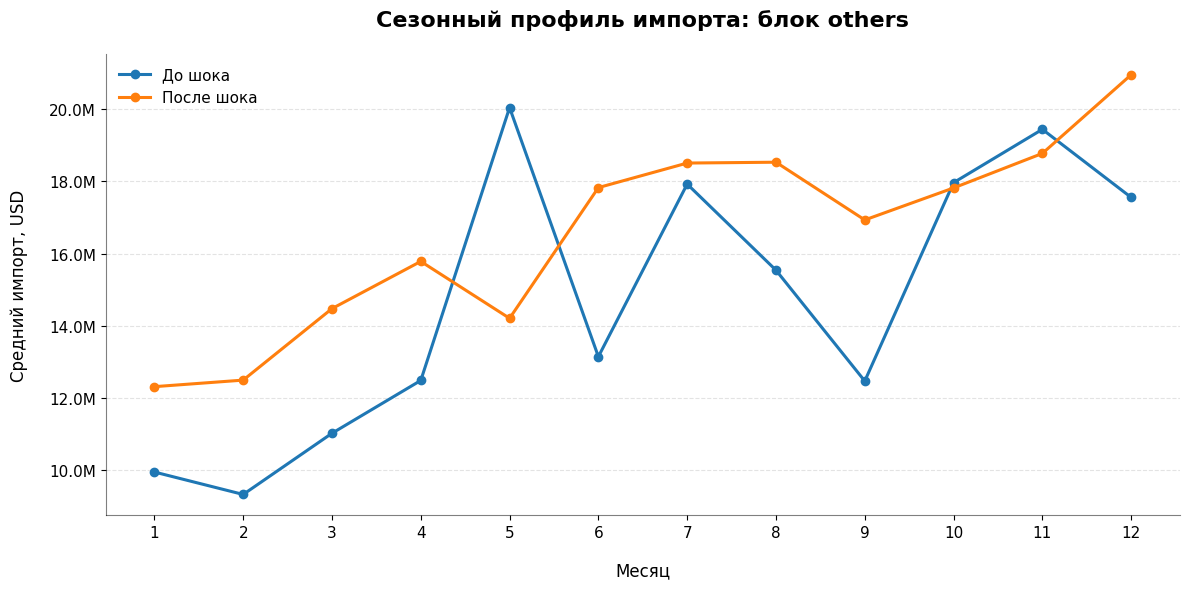

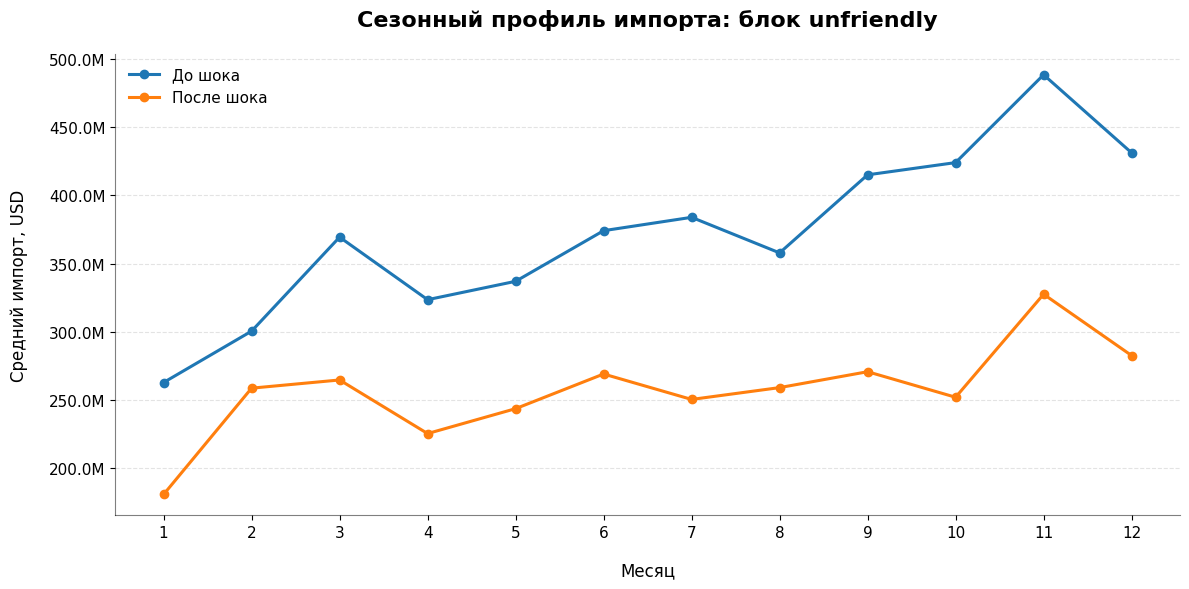

In [25]:
# PLOT SEASONAL PROFILES BY BLOC
for bloc_name, grp in bloc_monthly.groupby("bloc_exclusive"):
    season_profile_bloc = (
        grp.groupby(["post", "month"], as_index=False)["import_value"]
        .mean()
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    pre_prof = season_profile_bloc[season_profile_bloc["post"] == 0]
    post_prof = season_profile_bloc[season_profile_bloc["post"] == 1]

    ax.plot(pre_prof["month"], pre_prof["import_value"], marker="o", linewidth=2.2, label="До шока")
    ax.plot(post_prof["month"], post_prof["import_value"], marker="o", linewidth=2.2, label="После шока")
    ax.legend(frameon=False, fontsize=11)

    ax.set_xticks(range(1, 13))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

    apply_thesis_style(
        ax,
        title=f"Сезонный профиль импорта: блок {bloc_name}",
        ylabel="Средний импорт, USD",
        xlabel="Месяц",
        highlight_post_period=False
    )
    save_figure(fig, f"seasonal_profile_{bloc_name}")

In [26]:
# VARIANCE TEST FUNCTION
def run_variance_tests(x, y, label):
    lev_stat, lev_p = levene(x, y, center="mean")
    bf_stat, bf_p = levene(x, y, center="median")
    fl_stat, fl_p = fligner(x, y)
    bart_stat, bart_p = bartlett(x, y)

    return pd.DataFrame({
        "comparison": [label] * 4,
        "test": ["Levene", "Brown-Forsythe", "Fligner-Killeen", "Bartlett"],
        "statistic": [lev_stat, bf_stat, fl_stat, bart_stat],
        "pvalue": [lev_p, bf_p, fl_p, bart_p],
        "role": ["additional", "main", "main", "reference_only"]
    })

In [27]:
# VOLATILITY TESTS: AGGREGATE IMPORT (MAIN DESEASONALIZATION)
pre_main = agg_import.loc[agg_import["rep_date"] < shock_date, "resid_import_main"].dropna()
full_post_main = agg_import.loc[agg_import["rep_date"] >= shock_date, "resid_import_main"].dropna()
early_post_main = agg_import.loc[
    (agg_import["rep_date"] >= shock_date) & (agg_import["rep_date"] < early_post_end),
    "resid_import_main"
].dropna()
late_post_main = agg_import.loc[
    agg_import["rep_date"] >= early_post_end,
    "resid_import_main"
].dropna()

vol_full_main = run_variance_tests(pre_main, full_post_main, "Pre vs Full Post | main deseason")
vol_pre_early_main = run_variance_tests(pre_main, early_post_main, "Pre vs Early Post | main deseason")
vol_early_late_main = run_variance_tests(early_post_main, late_post_main, "Early Post vs Late Post | main deseason")
vol_pre_late_main = run_variance_tests(pre_main, late_post_main, "Pre vs Late Post | main deseason")

vol_results_main = pd.concat(
    [vol_full_main, vol_pre_early_main, vol_early_late_main, vol_pre_late_main],
    ignore_index=True
)

vol_results_main

,comparison,test,statistic,pvalue,role
0,Pre vs Full Post | main deseason,Levene,2.116024,0.149882,additional
1,Pre vs Full Post | main deseason,Brown-Forsythe,2.115859,0.149898,main
2,Pre vs Full Post | main deseason,Fligner-Killeen,1.950531,0.162530,main
3,Pre vs Full Post | main deseason,Bartlett,5.620194,0.017755,reference_only
4,Pre vs Early Post | main deseason,Levene,6.829771,0.011938,additional
5,Pre vs Early Post | main deseason,Brown-Forsythe,3.671434,0.061318,main
6,Pre vs Early Post | main deseason,Fligner-Killeen,1.168121,0.279788,main
7,Pre vs Early Post | main deseason,Bartlett,10.370458,0.001280,reference_only
8,Early Post vs Late Post | main deseason,Levene,3.326737,0.075832,additional
9,Early Post vs Late Post | main deseason,Brown-Forsythe,1.772825,0.190763,main


In [28]:
# VOLATILITY TESTS: AGGREGATE IMPORT (FOURIER DESEASONALIZATION)
pre_fourier = agg_import.loc[agg_import["rep_date"] < shock_date, "resid_import_fourier"].dropna()
full_post_fourier = agg_import.loc[agg_import["rep_date"] >= shock_date, "resid_import_fourier"].dropna()
early_post_fourier = agg_import.loc[
    (agg_import["rep_date"] >= shock_date) & (agg_import["rep_date"] < early_post_end),
    "resid_import_fourier"
].dropna()
late_post_fourier = agg_import.loc[
    agg_import["rep_date"] >= early_post_end,
    "resid_import_fourier"
].dropna()

vol_full_fourier = run_variance_tests(pre_fourier, full_post_fourier, "Pre vs Full Post | fourier deseason")
vol_pre_early_fourier = run_variance_tests(pre_fourier, early_post_fourier, "Pre vs Early Post | fourier deseason")
vol_early_late_fourier = run_variance_tests(early_post_fourier, late_post_fourier, "Early Post vs Late Post | fourier deseason")
vol_pre_late_fourier = run_variance_tests(pre_fourier, late_post_fourier, "Pre vs Late Post | fourier deseason")

vol_results_fourier = pd.concat(
    [vol_full_fourier, vol_pre_early_fourier, vol_early_late_fourier, vol_pre_late_fourier],
    ignore_index=True
)

vol_results_fourier

,comparison,test,statistic,pvalue,role
0,Pre vs Full Post | fourier deseason,Levene,1.864523,0.176132,additional
1,Pre vs Full Post | fourier deseason,Brown-Forsythe,1.957824,0.165814,main
2,Pre vs Full Post | fourier deseason,Fligner-Killeen,1.892680,0.168900,main
3,Pre vs Full Post | fourier deseason,Bartlett,1.661948,0.197340,reference_only
4,Pre vs Early Post | fourier deseason,Levene,4.168040,0.046710,additional
5,Pre vs Early Post | fourier deseason,Brown-Forsythe,2.836284,0.098650,main
6,Pre vs Early Post | fourier deseason,Fligner-Killeen,2.314555,0.128168,main
7,Pre vs Early Post | fourier deseason,Bartlett,3.721470,0.053717,reference_only
8,Early Post vs Late Post | fourier deseason,Levene,2.175675,0.148236,additional
9,Early Post vs Late Post | fourier deseason,Brown-Forsythe,1.371972,0.248580,main


In [29]:
# VOLATILITY TESTS: AGGREGATE IMPORT (STL DESEASONALIZATION)
pre_stl = agg_import.loc[agg_import["rep_date"] < shock_date, "resid_import_stl"].dropna()
full_post_stl = agg_import.loc[agg_import["rep_date"] >= shock_date, "resid_import_stl"].dropna()
early_post_stl = agg_import.loc[
    (agg_import["rep_date"] >= shock_date) & (agg_import["rep_date"] < early_post_end),
    "resid_import_stl"
].dropna()
late_post_stl = agg_import.loc[
    agg_import["rep_date"] >= early_post_end,
    "resid_import_stl"
].dropna()

vol_full_stl = run_variance_tests(pre_stl, full_post_stl, "Pre vs Full Post | STL deseason")
vol_pre_early_stl = run_variance_tests(pre_stl, early_post_stl, "Pre vs Early Post | STL deseason")
vol_early_late_stl = run_variance_tests(early_post_stl, late_post_stl, "Early Post vs Late Post | STL deseason")
vol_pre_late_stl = run_variance_tests(pre_stl, late_post_stl, "Pre vs Late Post | STL deseason")

vol_results_stl = pd.concat(
    [vol_full_stl, vol_pre_early_stl, vol_early_late_stl, vol_pre_late_stl],
    ignore_index=True
)

vol_results_stl

,comparison,test,statistic,pvalue,role
0,Pre vs Full Post | STL deseason,Levene,12.698453,6.362920e-04,additional
1,Pre vs Full Post | STL deseason,Brown-Forsythe,7.935937,6.172387e-03,main
2,Pre vs Full Post | STL deseason,Fligner-Killeen,11.046069,8.887544e-04,main
3,Pre vs Full Post | STL deseason,Bartlett,50.784023,1.031096e-12,reference_only
4,Pre vs Early Post | STL deseason,Levene,36.728293,2.027506e-07,additional
5,Pre vs Early Post | STL deseason,Brown-Forsythe,10.218236,2.460891e-03,main
6,Pre vs Early Post | STL deseason,Fligner-Killeen,5.482507,1.920770e-02,main
7,Pre vs Early Post | STL deseason,Bartlett,57.592431,3.224641e-14,reference_only
8,Early Post vs Late Post | STL deseason,Levene,8.773697,5.182741e-03,additional
9,Early Post vs Late Post | STL deseason,Brown-Forsythe,2.256903,1.410744e-01,main


In [30]:
vol_results_aggregate = pd.concat(
    [vol_results_main, vol_results_fourier, vol_results_stl],
    ignore_index=True
)

vol_results_aggregate

,comparison,test,statistic,pvalue,role
0,Pre vs Full Post | main deseason,Levene,2.116024,1.498823e-01,additional
1,Pre vs Full Post | main deseason,Brown-Forsythe,2.115859,1.498980e-01,main
2,Pre vs Full Post | main deseason,Fligner-Killeen,1.950531,1.625296e-01,main
3,Pre vs Full Post | main deseason,Bartlett,5.620194,1.775468e-02,reference_only
4,Pre vs Early Post | main deseason,Levene,6.829771,1.193755e-02,additional
5,Pre vs Early Post | main deseason,Brown-Forsythe,3.671434,6.131830e-02,main
6,Pre vs Early Post | main deseason,Fligner-Killeen,1.168121,2.797876e-01,main
7,Pre vs Early Post | main deseason,Bartlett,10.370458,1.280477e-03,reference_only
8,Early Post vs Late Post | main deseason,Levene,3.326737,7.583156e-02,additional
9,Early Post vs Late Post | main deseason,Brown-Forsythe,1.772825,1.907634e-01,main


In [31]:
# REGRESSION CHECK ON ABSOLUTE RESIDUALS
agg_import["period"] = "pre"
agg_import.loc[
    (agg_import["rep_date"] >= shock_date) & (agg_import["rep_date"] < early_post_end),
    "period"
] = "early_post"
agg_import.loc[
    agg_import["rep_date"] >= early_post_end,
    "period"
] = "late_post"

agg_import["period"] = agg_import["period"].astype("category")

abs_resid_model_main = smf.ols(
    "abs_resid_import_main ~ C(period)",
    data=agg_import
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

sq_resid_model_main = smf.ols(
    "sq_resid_import_main ~ C(period)",
    data=agg_import
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(abs_resid_model_main.summary())
print(sq_resid_model_main.summary())

                              OLS Regression Results                             
Dep. Variable:     abs_resid_import_main   R-squared:                       0.058
Model:                               OLS   Adj. R-squared:                  0.033
Method:                    Least Squares   F-statistic:                     1.159
Date:                   Mon, 27 Apr 2026   Prob (F-statistic):              0.319
Time:                           03:42:10   Log-Likelihood:                 95.000
No. Observations:                     78   AIC:                            -184.0
Df Residuals:                         75   BIC:                            -176.9
Df Model:                              2                                         
Covariance Type:                     HAC                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [32]:
# FUNCTION: DESEASONALIZE A BLOC AND TEST VOLATILITY
def analyze_bloc_volatility(bloc_df: pd.DataFrame, bloc_name: str) -> tuple:
    tmp = bloc_df.copy()

    # Main deseasonalization: month dummies
    model_main = smf.ols(
        "log_import ~ trend + C(month_cat)",
        data=tmp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    tmp["resid_main"] = model_main.resid

    # Alternative deseasonalization: Fourier terms
    model_fourier = smf.ols(
        "log_import ~ trend + sin1 + cos1 + sin2 + cos2",
        data=tmp
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    tmp["resid_fourier"] = model_fourier.resid

    # Alternative deseasonalization: STL
    stl = STL(
        tmp["log_import"],
        period=12,
        robust=True
    )
    stl_res = stl.fit()

    tmp["resid_stl"] = stl_res.resid
    tmp["stl_trend"] = stl_res.trend
    tmp["stl_seasonal"] = stl_res.seasonal

    # define periods for main
    pre_main = tmp.loc[tmp["rep_date"] < shock_date, "resid_main"].dropna()
    full_post_main = tmp.loc[tmp["rep_date"] >= shock_date, "resid_main"].dropna()
    early_post_main = tmp.loc[
        (tmp["rep_date"] >= shock_date) & (tmp["rep_date"] < early_post_end),
        "resid_main"
    ].dropna()
    late_post_main = tmp.loc[
        tmp["rep_date"] >= early_post_end,
        "resid_main"
    ].dropna()

    # define periods for Fourier
    pre_fourier = tmp.loc[tmp["rep_date"] < shock_date, "resid_fourier"].dropna()
    full_post_fourier = tmp.loc[tmp["rep_date"] >= shock_date, "resid_fourier"].dropna()
    early_post_fourier = tmp.loc[
        (tmp["rep_date"] >= shock_date) & (tmp["rep_date"] < early_post_end),
        "resid_fourier"
    ].dropna()
    late_post_fourier = tmp.loc[
        tmp["rep_date"] >= early_post_end,
        "resid_fourier"
    ].dropna()

    # define periods for STL
    pre_stl = tmp.loc[tmp["rep_date"] < shock_date, "resid_stl"].dropna()
    full_post_stl = tmp.loc[tmp["rep_date"] >= shock_date, "resid_stl"].dropna()
    early_post_stl = tmp.loc[
        (tmp["rep_date"] >= shock_date) & (tmp["rep_date"] < early_post_end),
        "resid_stl"
    ].dropna()
    late_post_stl = tmp.loc[
        tmp["rep_date"] >= early_post_end,
        "resid_stl"
    ].dropna()

    # main results
    res_main = pd.concat([
        run_variance_tests(pre_main, full_post_main, f"{bloc_name} | Pre vs Full Post | main"),
        run_variance_tests(pre_main, early_post_main, f"{bloc_name} | Pre vs Early Post | main"),
        run_variance_tests(early_post_main, late_post_main, f"{bloc_name} | Early vs Late Post | main"),
        run_variance_tests(pre_main, late_post_main, f"{bloc_name} | Pre vs Late Post | main"),
    ], ignore_index=True)

    # fourier results
    res_fourier = pd.concat([
        run_variance_tests(pre_fourier, full_post_fourier, f"{bloc_name} | Pre vs Full Post | fourier"),
        run_variance_tests(pre_fourier, early_post_fourier, f"{bloc_name} | Pre vs Early Post | fourier"),
        run_variance_tests(early_post_fourier, late_post_fourier, f"{bloc_name} | Early vs Late Post | fourier"),
        run_variance_tests(pre_fourier, late_post_fourier, f"{bloc_name} | Pre vs Late Post | fourier"),
    ], ignore_index=True)

    # STL results
    res_stl = pd.concat([
        run_variance_tests(pre_stl, full_post_stl, f"{bloc_name} | Pre vs Full Post | STL"),
        run_variance_tests(pre_stl, early_post_stl, f"{bloc_name} | Pre vs Early Post | STL"),
        run_variance_tests(early_post_stl, late_post_stl, f"{bloc_name} | Early vs Late Post | STL"),
        run_variance_tests(pre_stl, late_post_stl, f"{bloc_name} | Pre vs Late Post | STL"),
    ], ignore_index=True)

    # rolling volatility helper
    tmp["roll12_std_main"] = tmp["resid_main"].rolling(12, min_periods=6).std()
    tmp["roll12_std_fourier"] = tmp["resid_fourier"].rolling(12, min_periods=6).std()
    tmp["roll12_std_stl"] = tmp["resid_stl"].rolling(12, min_periods=6).std()

    return tmp, model_main, model_fourier, stl_res, res_main, res_fourier, res_stl

In [33]:
bloc_volatility_results = []
bloc_processed = {}

for bloc_name, grp in bloc_monthly.groupby("bloc_exclusive"):
    tmp, model_main, model_fourier, stl_res, res_main, res_fourier, res_stl = analyze_bloc_volatility(grp.copy(), bloc_name)

    bloc_processed[bloc_name] = {
        "data": tmp,
        "model_main": model_main,
        "model_fourier": model_fourier,
        "stl_res": stl_res
    }

    bloc_volatility_results.append(res_main)
    bloc_volatility_results.append(res_fourier)
    bloc_volatility_results.append(res_stl)

bloc_volatility_results = pd.concat(bloc_volatility_results, ignore_index=True)
bloc_volatility_results

,comparison,test,statistic,pvalue,role
0,brics | Pre vs Full Post | main,Levene,2.555088,1.140892e-01,additional
1,brics | Pre vs Full Post | main,Brown-Forsythe,2.557175,1.139440e-01,main
2,brics | Pre vs Full Post | main,Fligner-Killeen,3.357283,6.690839e-02,main
3,brics | Pre vs Full Post | main,Bartlett,0.832180,3.616429e-01,reference_only
4,brics | Pre vs Early Post | main,Levene,2.646555,1.103225e-01,additional
...,...,...,...,...,...
187,unfriendly | Early vs Late Post | STL,Bartlett,2.595196,1.071882e-01,reference_only
188,unfriendly | Pre vs Late Post | STL,Levene,18.412405,6.241896e-05,additional
189,unfriendly | Pre vs Late Post | STL,Brown-Forsythe,7.170489,9.439260e-03,main
190,unfriendly | Pre vs Late Post | STL,Fligner-Killeen,5.284166,2.152020e-02,main


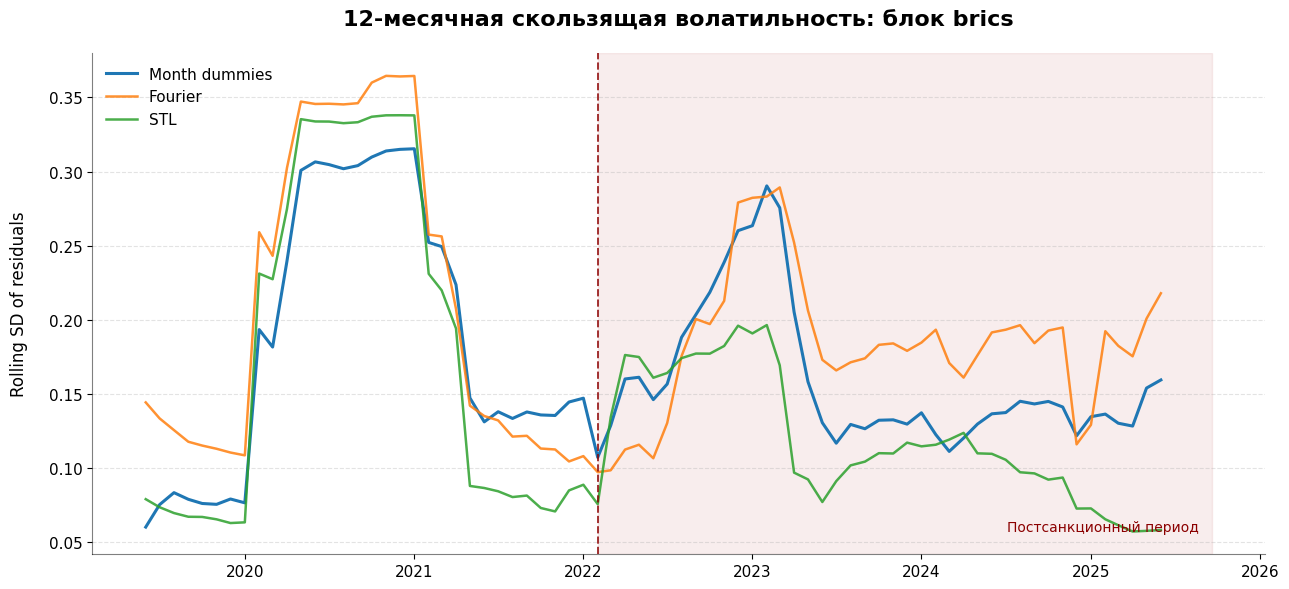

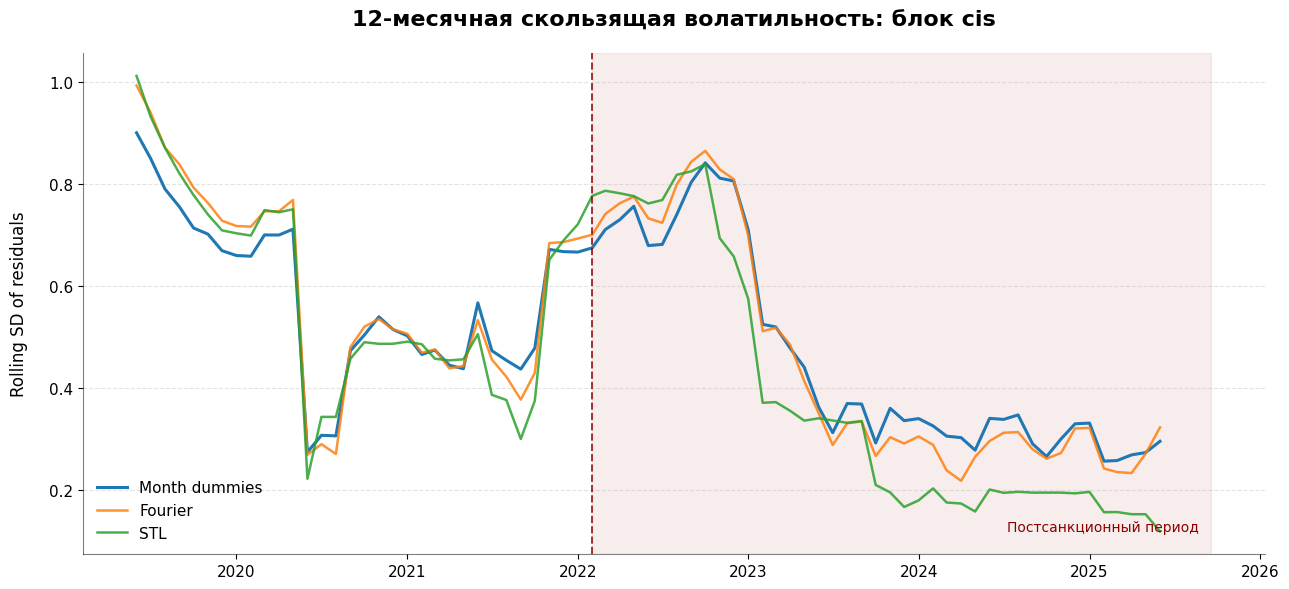

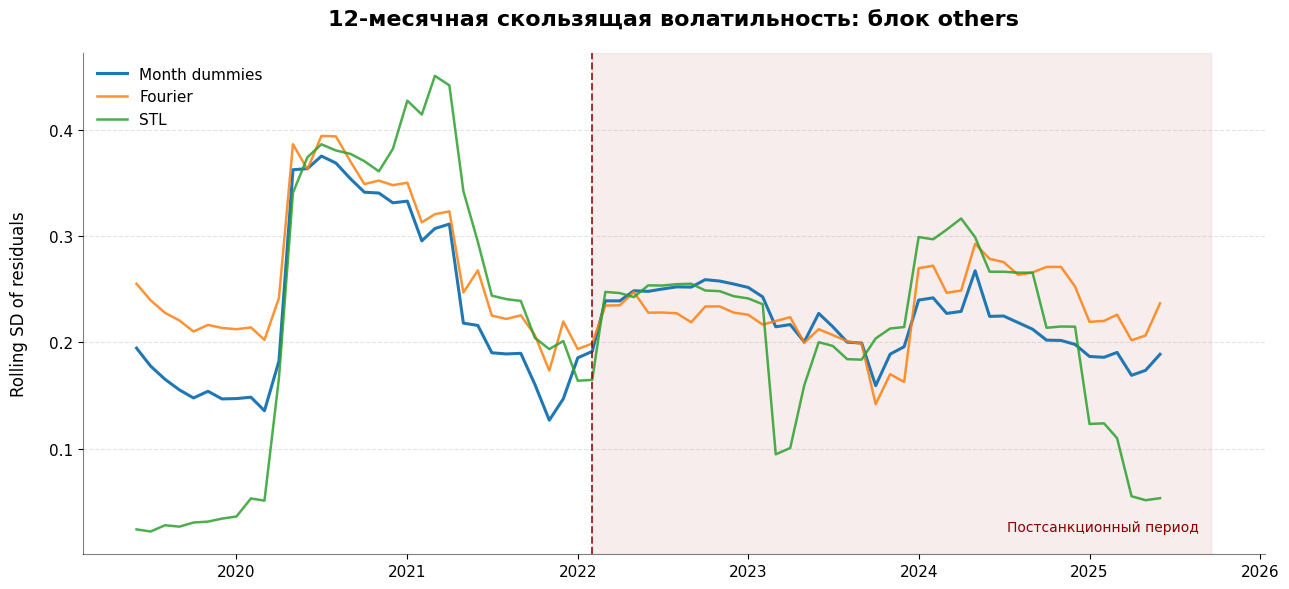

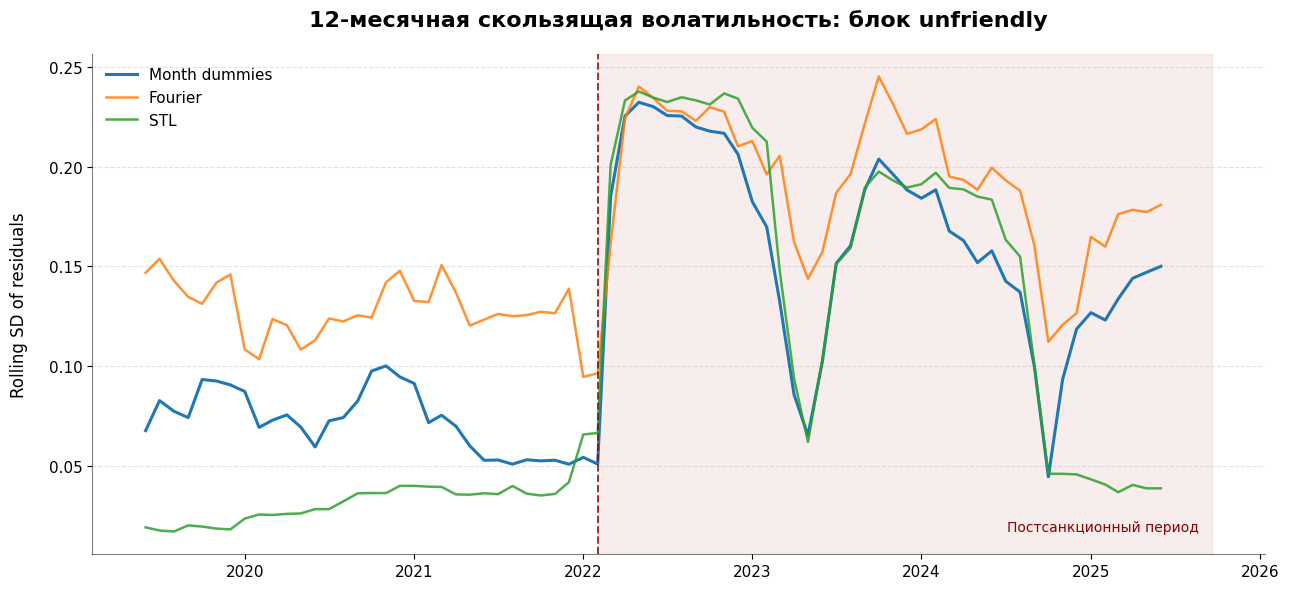

In [34]:
for bloc_name, content in bloc_processed.items():
    tmp = content["data"]

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(tmp["rep_date"], tmp["roll12_std_main"], linewidth=2.2, label="Month dummies")
    ax.plot(tmp["rep_date"], tmp["roll12_std_fourier"], linewidth=1.8, alpha=0.85, label="Fourier")
    ax.plot(tmp["rep_date"], tmp["roll12_std_stl"], linewidth=1.8, alpha=0.85, label="STL")

    ax.legend(frameon=False, fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    apply_thesis_style(
        ax,
        title=f"12-месячная скользящая волатильность: блок {bloc_name}",
        ylabel="Rolling SD of residuals"
    )
    save_figure(fig, f"rolling_volatility_{bloc_name}")